In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, month, count, lpad, when, concat, lit, avg, hour, sum, dayofweek
from helper_functions import draw_region_map, draw_zone_map
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
from pyspark.sql import functions as F


import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import shapefile

In [2]:
spark_session = (SparkSession.builder
                    .master('local[*]')
                    .config("spark.executor.memory", "8g")
                    .config("spark.driver.memory", "8g")
                    .appName('SparkProcessing')
                    .getOrCreate()) 

df = spark_session.read.parquet(
    "trip_data_clean.parquet",
    header=True,
    inferSchema=True
)

df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RateCodeID: integer (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- trip_duration: double (nullable = true)
 |-- hour: integer (nullable = true)
 |-- time_of_day: string (nullable = true)


Correlation matrix

In [14]:
corr_df = df.drop("tpep_pickup_datetime", "tpep_dropoff_datetime", "VendorID", "RateCodeID", "PULocationID", "DOLocationID", "payment_type", "time_of_day")
vector_col = "corr_features"
assembler = VectorAssembler(inputCols=corr_df.columns, outputCol=vector_col)
df_vector = assembler.transform(corr_df).select(vector_col)

matrix = Correlation.corr(df_vector, vector_col)
correlation_matrix = matrix.collect()[0]["pearson({})".format(vector_col)].values.reshape(7,7)

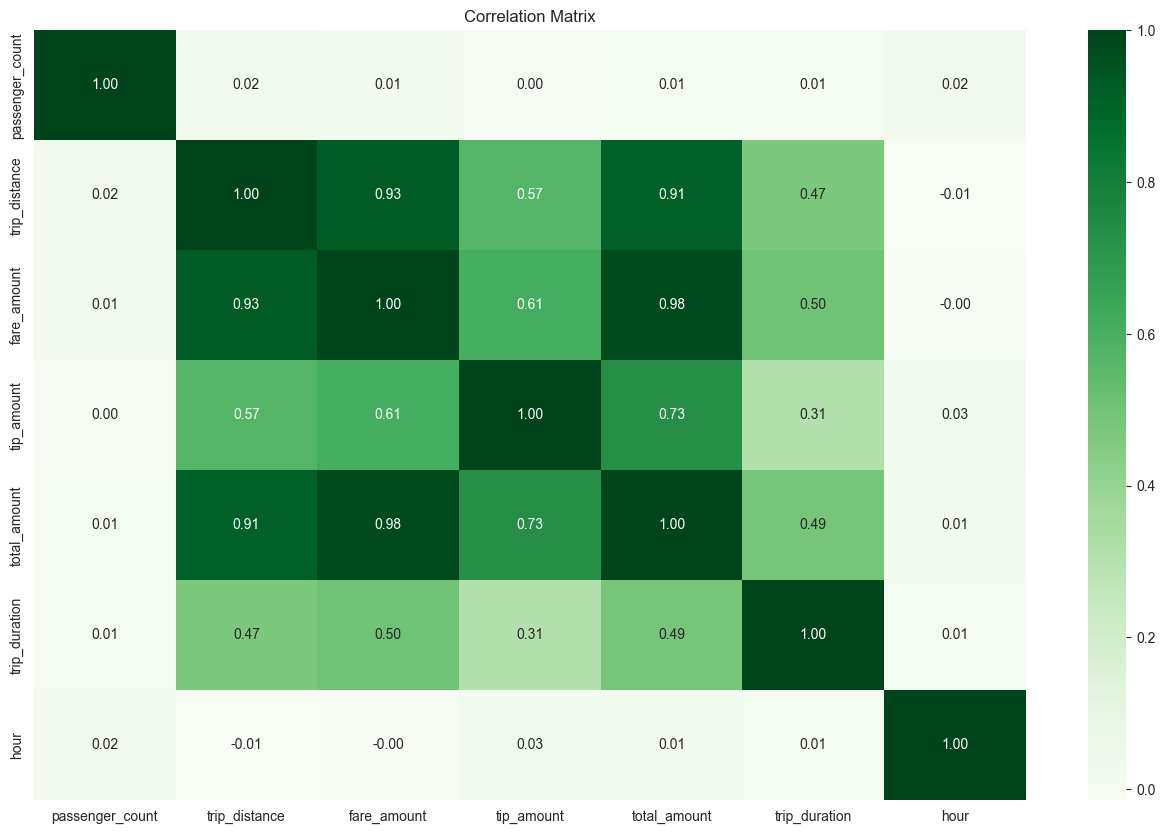

In [13]:
plt.figure(figsize=(16, 10))
sns.heatmap(correlation_matrix, xticklabels=corr_df.columns, yticklabels=corr_df.columns, fmt=".2f", cmap="Greens", annot=True)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
corr_df = df.drop("tpep_pickup_datetime", "tpep_dropoff_datetime", "time_of_day")
vector_col = "corr_features"
assembler = VectorAssembler(inputCols=corr_df.columns, outputCol=vector_col)
df_vector = assembler.transform(corr_df).select(vector_col)

matrix = Correlation.corr(df_vector, vector_col)
correlation_matrix = matrix.collect()[0]["pearson({})".format(vector_col)].values.reshape(7,7)

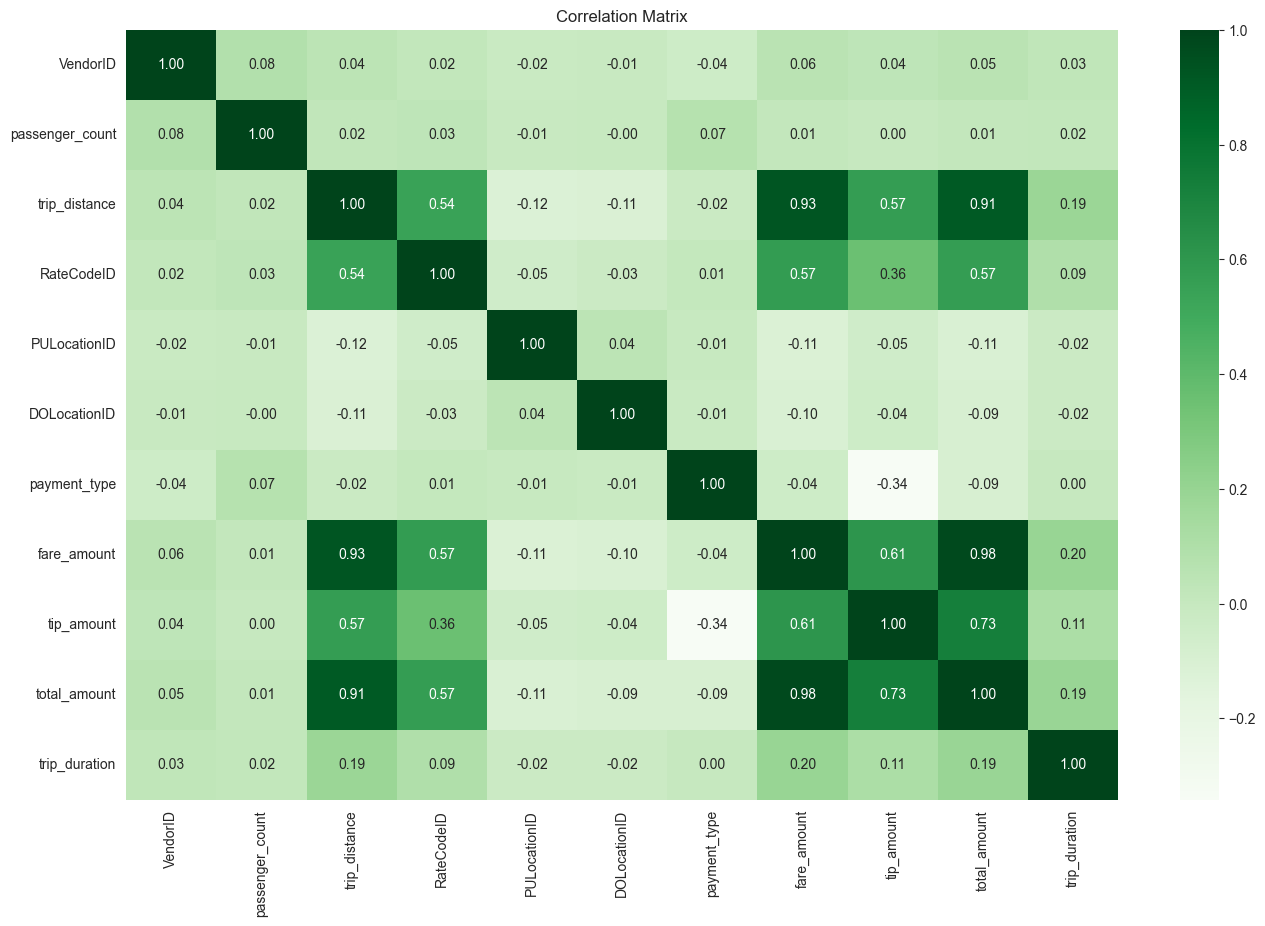

In [76]:
plt.figure(figsize=(16, 10))
sns.heatmap(correlation_matrix, xticklabels=corr_df.columns, yticklabels=corr_df.columns, fmt=".2f", cmap="Greens", annot=True)
plt.title("Correlation Matrix")
plt.show()

Correlation between trip_counts by day and other variables

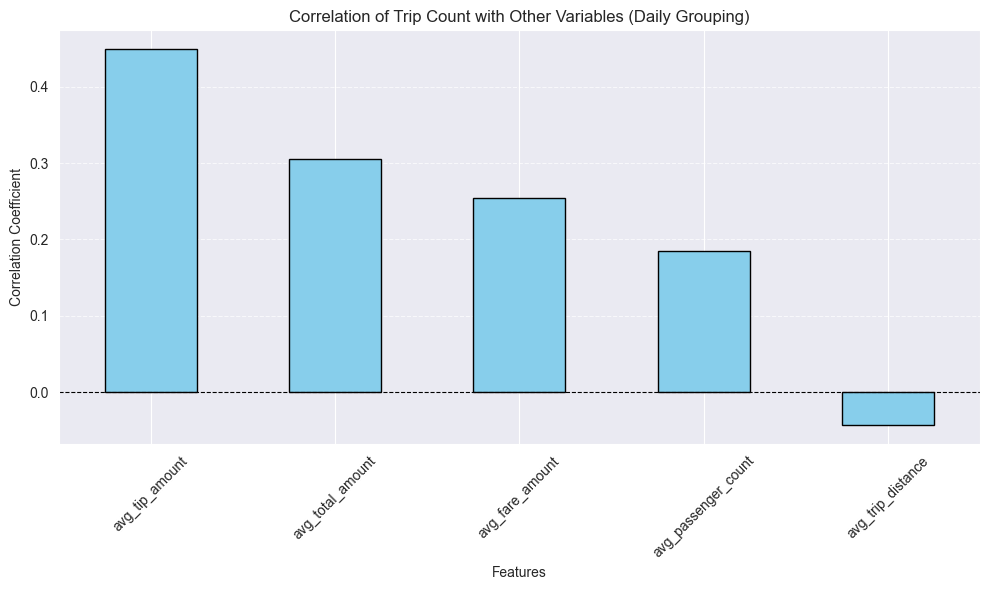

In [103]:
df_daily_trips = df.withColumn("year", F.year("tpep_pickup_datetime")) \
                   .withColumn("day", F.date_format("tpep_pickup_datetime", "yyyy-MM-dd")) \
                   .groupBy("year", "day") \
                   .agg(F.count("*").alias("trip_count"))

numerical_cols = ["fare_amount", "trip_distance", "total_amount", "tip_amount", "passenger_count"]

numerical_agg = df.withColumn("year", F.year("tpep_pickup_datetime")) \
                  .withColumn("day", F.date_format("tpep_pickup_datetime", "yyyy-MM-dd")) \
                  .groupBy("year", "day") \
                  .agg(*[F.avg(col).alias(f"avg_{col}") for col in numerical_cols])

df_combined = df_daily_trips.join(numerical_agg, on=["year", "day"], how="inner")

df_combined_pandas = df_combined.toPandas()

correlation_matrix = df_combined_pandas.drop("year", axis=1).drop("day", axis=1).corr()

trip_count_corr = correlation_matrix["trip_count"].drop("trip_count")

plt.figure(figsize=(10, 6))
trip_count_corr.sort_values(ascending=False).plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Correlation of Trip Count with Other Variables (Daily Grouping)")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

Growth of tips, fares, total paid and trip distances over months

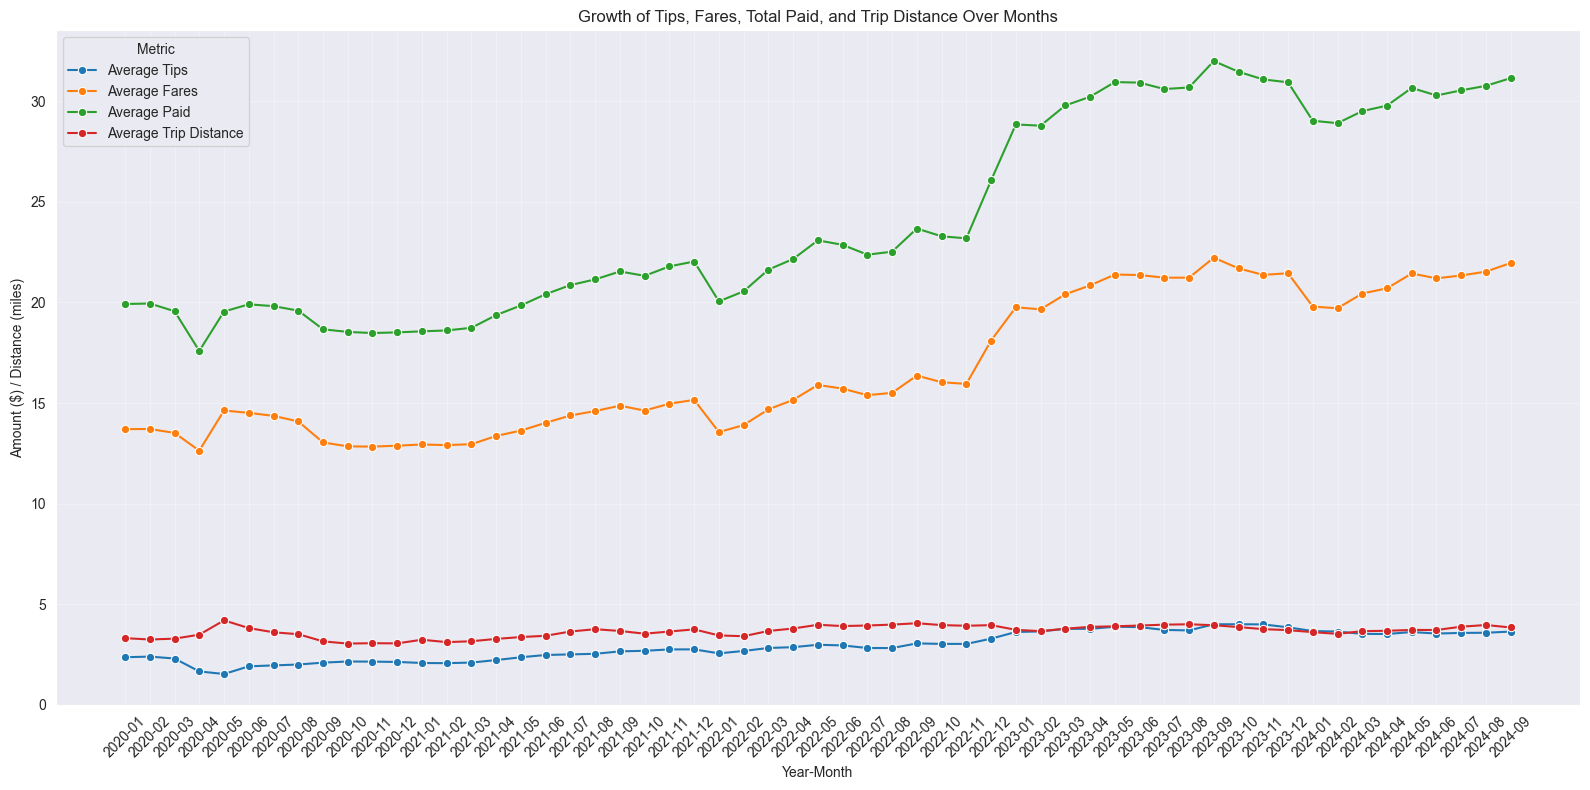

In [6]:
df_monthly = df.withColumn("year", F.year("tpep_pickup_datetime")) \
               .withColumn("month", F.month("tpep_pickup_datetime")) \
               .groupBy("year", "month") \
               .agg(
                   F.avg("tip_amount").alias("average_tips"),
                   F.avg("fare_amount").alias("average_fares"),
                   F.avg("total_amount").alias("average_paid"),
                   F.avg("trip_distance").alias("average_trip_distance")
               )

df_monthly_pandas = df_monthly.toPandas()

df_monthly_pandas["year_month"] = (
    df_monthly_pandas["year"].astype(str) + "-" +
    df_monthly_pandas["month"].astype(str).str.zfill(2)
)
df_monthly_pandas.sort_values("year_month", inplace=True)

plt.figure(figsize=(16, 8))

sns.lineplot(data=df_monthly_pandas, x="year_month", y="average_tips", label="Average Tips", marker="o")
sns.lineplot(data=df_monthly_pandas, x="year_month", y="average_fares", label="Average Fares", marker="o")
sns.lineplot(data=df_monthly_pandas, x="year_month", y="average_paid", label="Average Paid", marker="o")
sns.lineplot(data=df_monthly_pandas, x="year_month", y="average_trip_distance", label="Average Trip Distance", marker="o")

plt.title("Growth of Tips, Fares, Total Paid, and Trip Distance Over Months")
plt.xlabel("Year-Month")
plt.ylabel("Amount ($) / Distance (miles)")
plt.xticks(rotation=45)
plt.legend(title="Metric")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Correlation between trip counts and passenger count

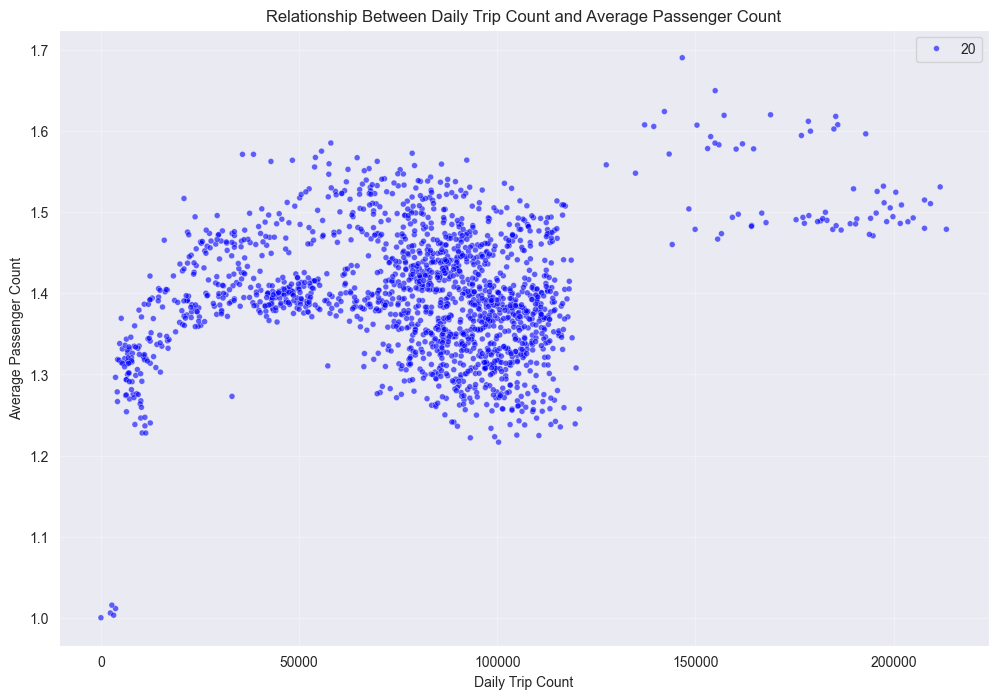

In [139]:
df_daily = df.withColumn("day", F.to_date("tpep_pickup_datetime")) \
             .groupBy("day") \
             .agg(
                 F.count("*").alias("trip_count"),
                 F.avg("passenger_count").alias("avg_person_count")
             )

df_daily_pandas = df_daily.toPandas()

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_daily_pandas,
    x="trip_count",
    y="avg_person_count",
    alpha=0.6,
    color="blue",
    size=20
)

plt.title("Relationship Between Daily Trip Count and Average Passenger Count")
plt.xlabel("Daily Trip Count")
plt.ylabel("Average Passenger Count")
plt.grid(alpha=0.3,)

plt.show()

In [7]:
fhv = spark_session.read.format("parquet").load("Dataset/*/high_volume_for_hire_vehicle/*",
                                   schema="pickup_datetime timestamp_ntz, hvfhs_license_num string")
fhv.printSchema()

root
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- hvfhs_license_num: string (nullable = true)


Comparing yellow taxis vs uber and lyft

Pearson Correlation between Yellow Taxi and Uber: 0.84
Pearson Correlation between Yellow Taxi and Lyft: 0.80


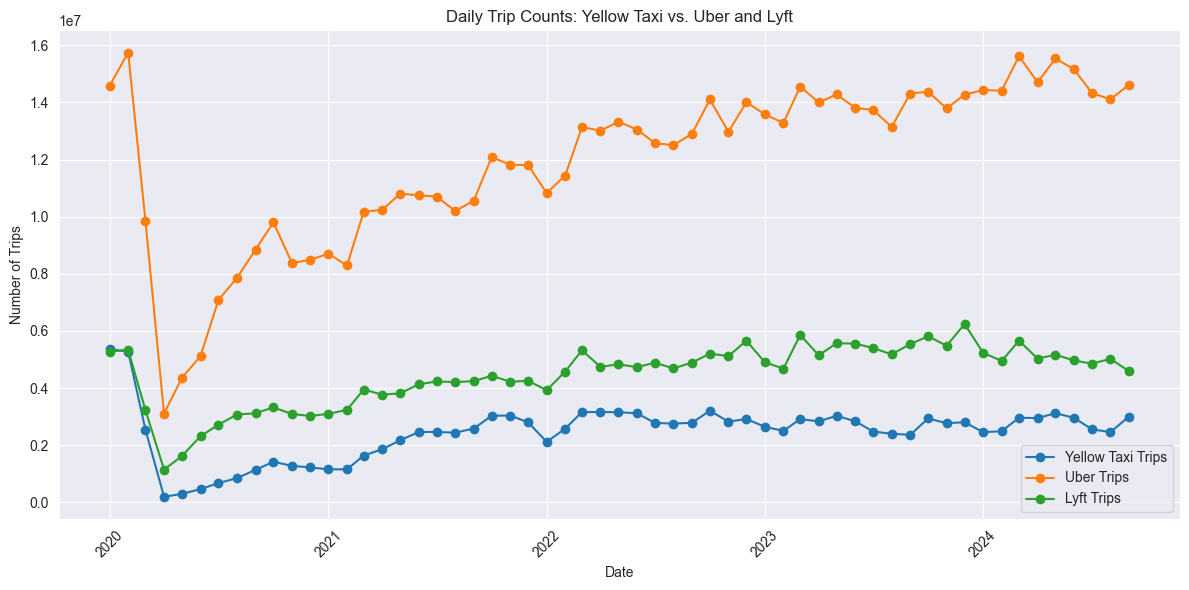

In [8]:
from pyspark.sql.functions import year, month, dayofmonth, count, col, lpad, concat, lit
import pandas as pd
import matplotlib.pyplot as plt

yellow_taxi_df = df.withColumn("year", year("tpep_pickup_datetime")) \
                               .withColumn("month", lpad(month("tpep_pickup_datetime").cast("string"), 2, "0")) \
                               .withColumn("date", concat(col("year"), lit("-"), col("month"))) \
                               .groupBy("date") \
                               .agg(count("*").alias("yellow_taxi_trips"))

uber_lyft_juno_via_df = fhv.withColumn("year", year("pickup_datetime")) \
                            .withColumn("month", lpad(month("pickup_datetime").cast("string"), 2, "0")) \
                            .withColumn("date", concat(col("year"), lit("-"), col("month")))

company_trips_df = uber_lyft_juno_via_df.groupBy("date", "hvfhs_license_num") \
                                         .agg(count("*").alias("company_trips"))

uber_df = company_trips_df.filter(col("hvfhs_license_num") == "HV0003") \
                           .withColumnRenamed("company_trips", "uber_trips")

lyft_df = company_trips_df.filter(col("hvfhs_license_num") == "HV0005") \
                           .withColumnRenamed("company_trips", "lyft_trips")

combined_df = yellow_taxi_df.join(uber_df, on="date", how="outer") \
                            .join(lyft_df, on="date", how="outer") \
                            .fillna(0)

combined_df_pandas = combined_df.toPandas()

combined_df_pandas['date'] = pd.to_datetime(combined_df_pandas['date'], format='%Y-%m')

combined_df_pandas = combined_df_pandas.sort_values(by='date')

correlation_uber_yellow = combined_df_pandas["yellow_taxi_trips"].corr(combined_df_pandas["uber_trips"])
correlation_lyft_yellow = combined_df_pandas["yellow_taxi_trips"].corr(combined_df_pandas["lyft_trips"])

print(f"Pearson Correlation between Yellow Taxi and Uber: {correlation_uber_yellow:.2f}")
print(f"Pearson Correlation between Yellow Taxi and Lyft: {correlation_lyft_yellow:.2f}")

plt.figure(figsize=(12, 6))
plt.plot(combined_df_pandas["date"], combined_df_pandas["yellow_taxi_trips"], marker='o', label="Yellow Taxi Trips")
plt.plot(combined_df_pandas["date"], combined_df_pandas["uber_trips"], marker='o', label="Uber Trips")
plt.plot(combined_df_pandas["date"], combined_df_pandas["lyft_trips"], marker='o', label="Lyft Trips")

plt.title("Daily Trip Counts: Yellow Taxi vs. Uber and Lyft")
plt.xlabel("Date")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Heatmap for count of trips based on weekdays and time

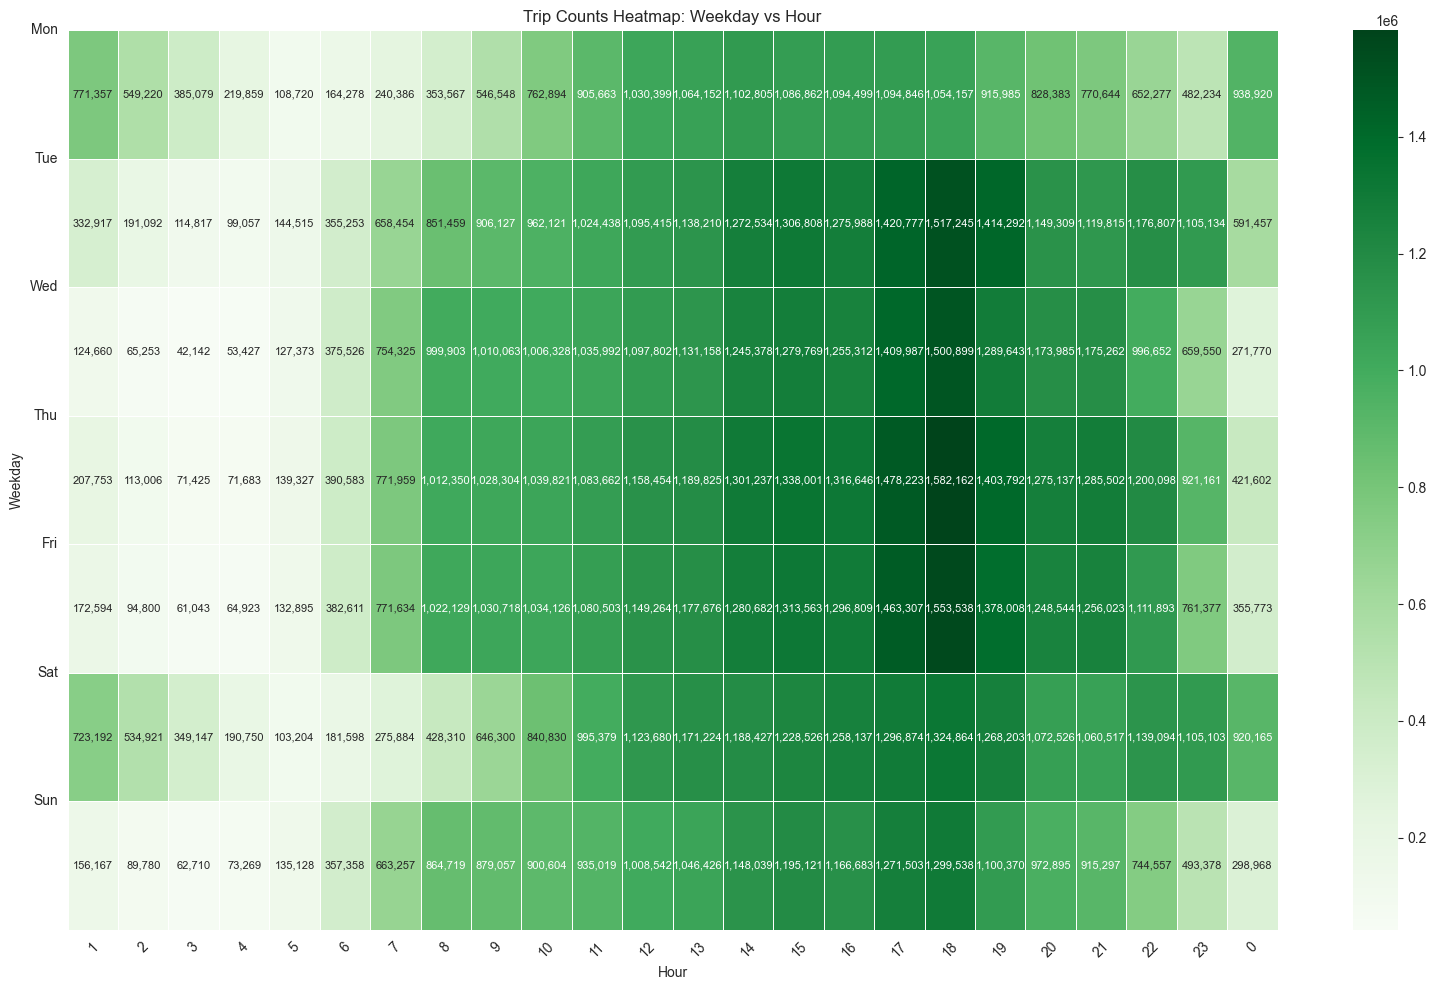

In [99]:
df_with_hour_weekday = df.withColumn("hour", F.hour("tpep_pickup_datetime")) \
                         .withColumn("weekday", F.dayofweek("tpep_pickup_datetime"))

df_hour_weekday_trip_count = df_with_hour_weekday.groupBy("hour", "weekday") \
    .agg(F.count("*").alias("trip_count"))

df_pivoted = df_hour_weekday_trip_count.groupBy("weekday") \
    .pivot("hour", [(i+1)%24 for i in range(24)]) \
    .agg(F.first("trip_count"))

df_pivoted_pandas = df_pivoted.toPandas()

plt.figure(figsize=(16, 10))  # Increase the figure size
sns.heatmap(df_pivoted_pandas.set_index('weekday').fillna(0), annot=True, cmap="Greens", fmt=',.0f', 
            linewidths=0.5, annot_kws={"size": 8})  # Use ',.0f' format to prevent scientific notation

plt.title('Trip Counts Heatmap: Weekday vs Hour')
plt.ylabel('Weekday')
plt.xlabel('Hour')
plt.yticks(ticks=[0, 1, 2, 3, 4, 5, 6], labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)
plt.xticks(rotation=45)  
plt.tight_layout()

plt.show()

Relation between fare amount and time

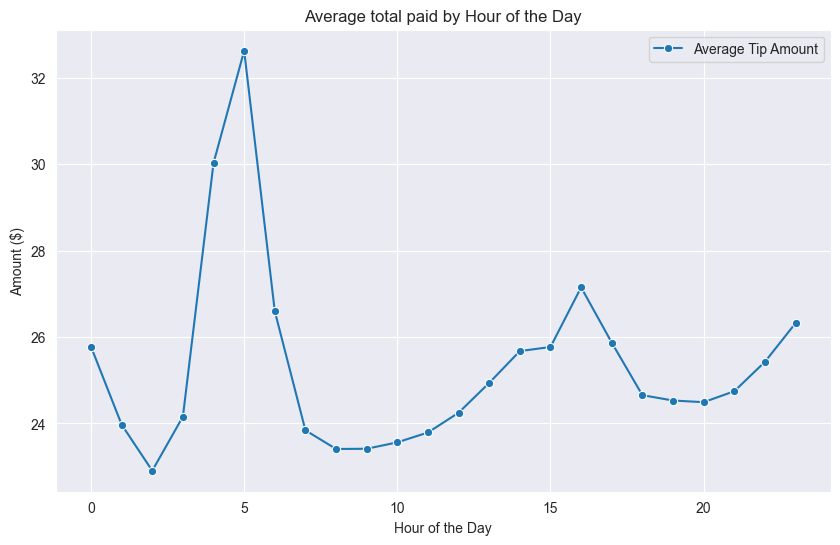

In [101]:
df_with_hour = df.withColumn("pickup_hour", hour(df.tpep_pickup_datetime))

result = df_with_hour.groupBy("pickup_hour").agg(
    avg("total_amount").alias("avg_total_amount"),
)

result_pandas = result.toPandas()

plt.figure(figsize=(10, 6))

sns.lineplot(x='pickup_hour', y='avg_total_amount', data=result_pandas, label='Average Tip Amount', marker='o')

plt.xlabel('Hour of the Day')
plt.ylabel('Amount ($)')
plt.title('Average total paid by Hour of the Day')
plt.legend()

plt.grid(True)
plt.show()

Ration between different payment types

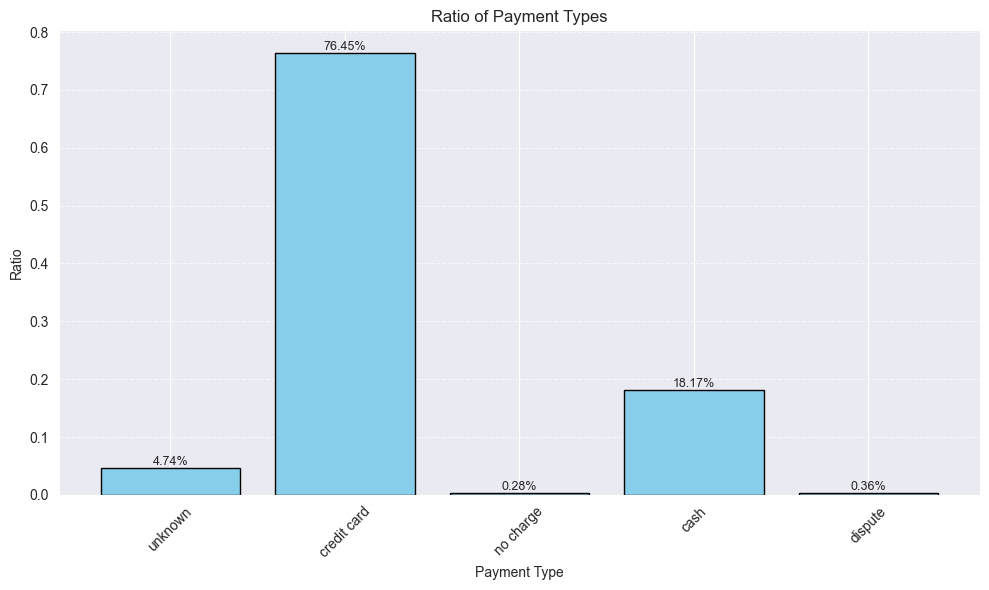

In [149]:
payment_type_mapping = {
    0: 'unknown',
    1: 'credit card',
    2: 'cash',
    3: 'no charge',
    4: 'dispute'
}

payment_type_counts = df.groupBy("payment_type").agg(F.count("*").alias("count"))
total_trips = payment_type_counts.select(F.sum("count")).collect()[0][0]

payment_type_ratios = payment_type_counts.withColumn("ratio", F.col("count") / total_trips)

payment_type_ratios_pandas = payment_type_ratios.toPandas()

payment_type_ratios_pandas["payment_type_name"] = payment_type_ratios_pandas["payment_type"].map(payment_type_mapping)

plt.figure(figsize=(10, 6))
plt.bar(payment_type_ratios_pandas["payment_type_name"], payment_type_ratios_pandas["ratio"], color="skyblue", edgecolor="black")

plt.title("Ratio of Payment Types")
plt.xlabel("Payment Type")
plt.ylabel("Ratio")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

for i, ratio in enumerate(payment_type_ratios_pandas["ratio"]):
    plt.text(i, ratio + 0.005, f"{ratio:.2%}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

What zones are most popular

In [19]:
df_pu = df.groupBy("PULocationID").agg(count("*").alias("PUcount")).withColumnRenamed("PULocationID", "LocationID")
df_do = df.groupBy("DOLocationID").agg(count("*").alias("DOcount")).withColumnRenamed("DOLocationID", "LocationID")

df_q1 = df_pu.join(df_do, on="LocationID", how="outer").fillna(0)

df_q1 = df_q1.withColumn("TOTALcount", col("PUcount") + col("DOcount"))

df_q1 = df_q1.orderBy("LocationID")


PUtop3 = df_q1.orderBy(col("PUcount").desc()).limit(3).toPandas()
DOtop3 = df_q1.orderBy(col("DOcount").desc()).limit(3).toPandas()

PUcount = {row["LocationID"]: row["PUcount"] for row in df_q1.collect()}
DOcount = {row["LocationID"]: row["DOcount"] for row in df_q1.collect()}


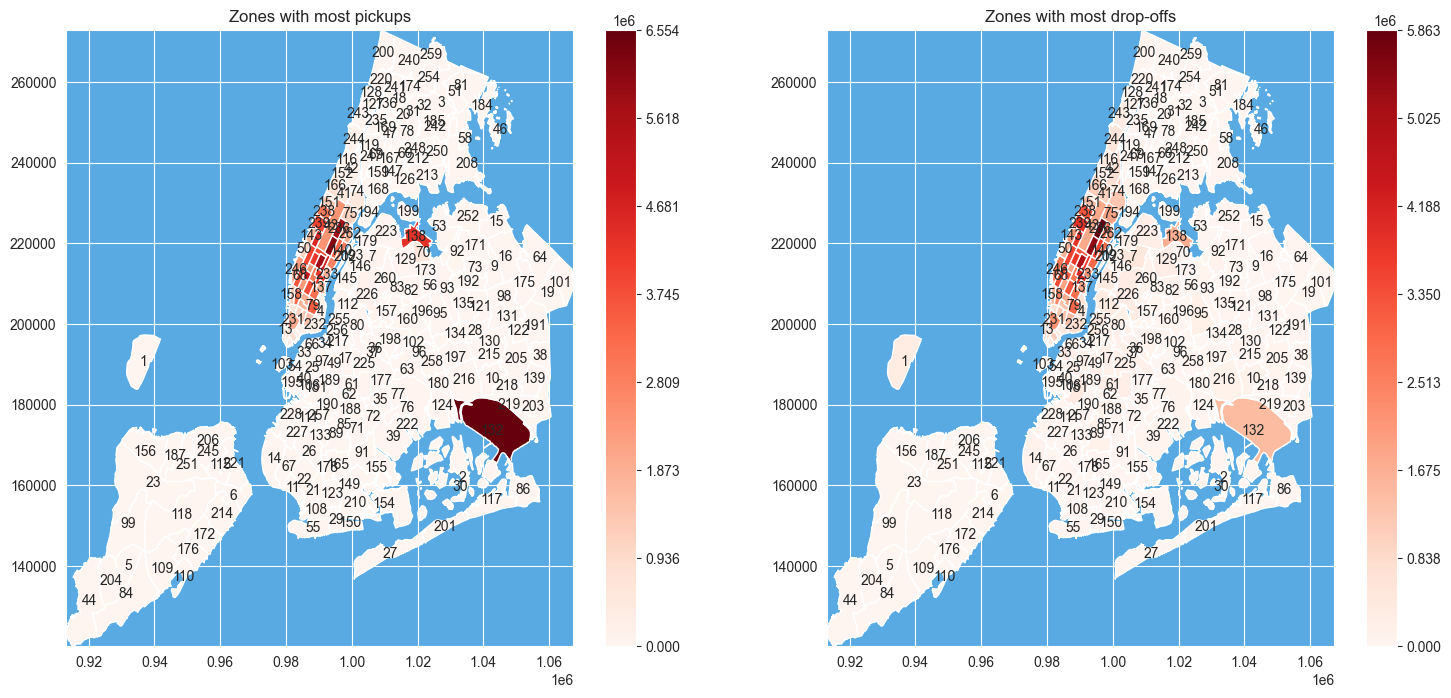

In [106]:
sf = shapefile.Reader("Dataset/Map/taxi_zones.shp")
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,8))
ax = plt.subplot(1, 2, 1)
ax.set_title("Zones with most pickups")
draw_zone_map(ax, sf, heat=PUcount)
ax = plt.subplot(1, 2, 2)
ax.set_title("Zones with most drop-offs")
draw_zone_map(ax, sf, heat=DOcount)

What zones are most expensive

In [104]:
df_pu_avg = df.groupBy("PULocationID").agg(F.avg("total_amount").alias("avg_total_paid_pu")) \
    .withColumnRenamed("PULocationID", "LocationID")

df_do_avg = df.groupBy("DOLocationID").agg(F.avg("total_amount").alias("avg_total_paid_do")) \
    .withColumnRenamed("DOLocationID", "LocationID")

pickup_avg_dict = {row["LocationID"]: row["avg_total_paid_pu"] for row in df_pu_avg.collect()}

dropoff_avg_dict = {row["LocationID"]: row["avg_total_paid_do"] for row in df_do_avg.collect()}

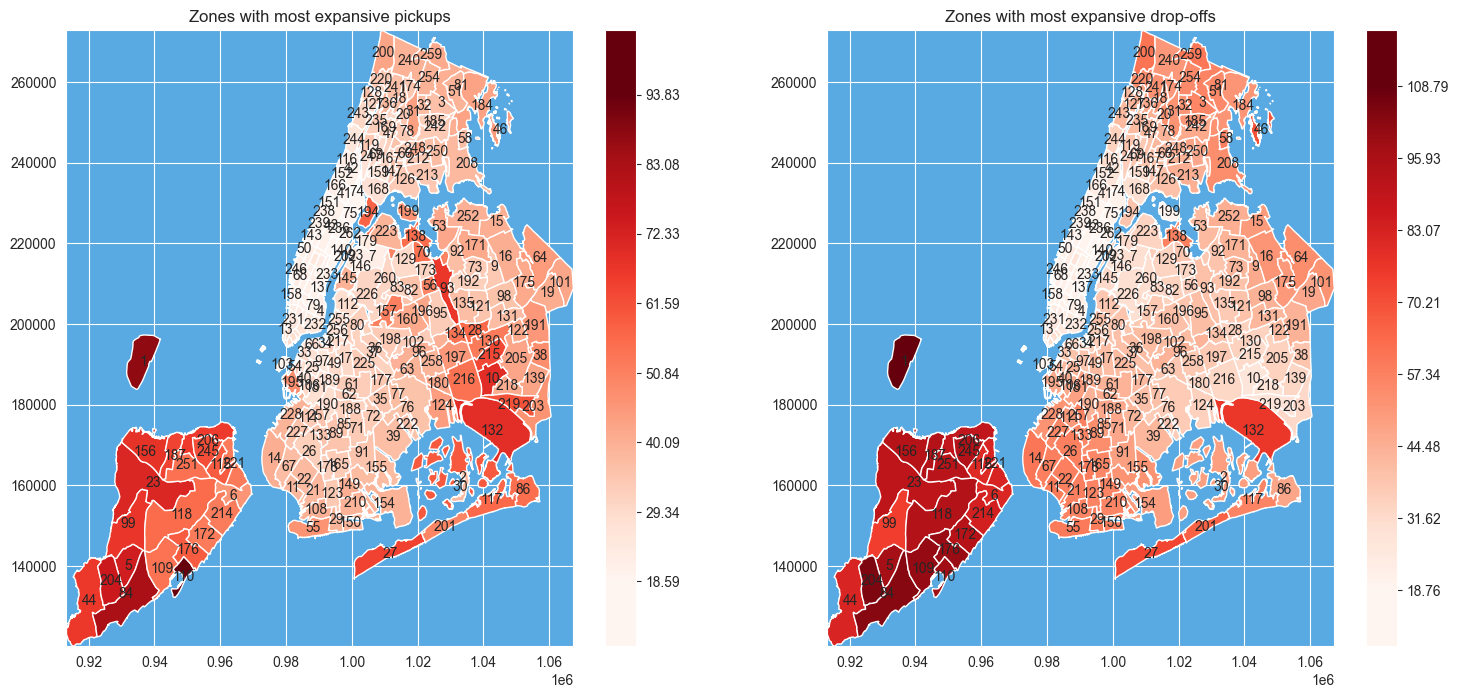

In [105]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,8))
ax = plt.subplot(1, 2, 1)
ax.set_title("Zones with most expensive pickups")
draw_zone_map(ax, sf, heat=pickup_avg_dict)
ax = plt.subplot(1, 2, 2)
ax.set_title("Zones with most expensive drop-offs")
draw_zone_map(ax, sf, heat=dropoff_avg_dict)

Most popular boroughs based on time of the day

In [133]:
taxi_zone_lookup = spark_session.read.option("header", "true").csv("Dataset/taxi_zone_lookup.csv")
taxi_zone_lookup = taxi_zone_lookup.withColumn("LocationID", F.col("LocationID").cast("bigint"))
taxi_zone_lookup = taxi_zone_lookup.withColumnRenamed("LocationID", "DOLocationID")

df_with_borough = df.join(taxi_zone_lookup, on="DOLocationID", how="inner")
df_aggregated = df_with_borough.groupBy("borough", "time_of_day") \
                               .agg(F.count("*").alias("count"))

borough_time_of_day_dict = {}

for row in df_aggregated.collect():
    total_count = row["count"]
    borough = row["borough"]
    time_of_day = row["time_of_day"]
    
    if time_of_day not in borough_time_of_day_dict:
        borough_time_of_day_dict[time_of_day] = {}
    
    borough_time_of_day_dict[time_of_day][borough] = total_count

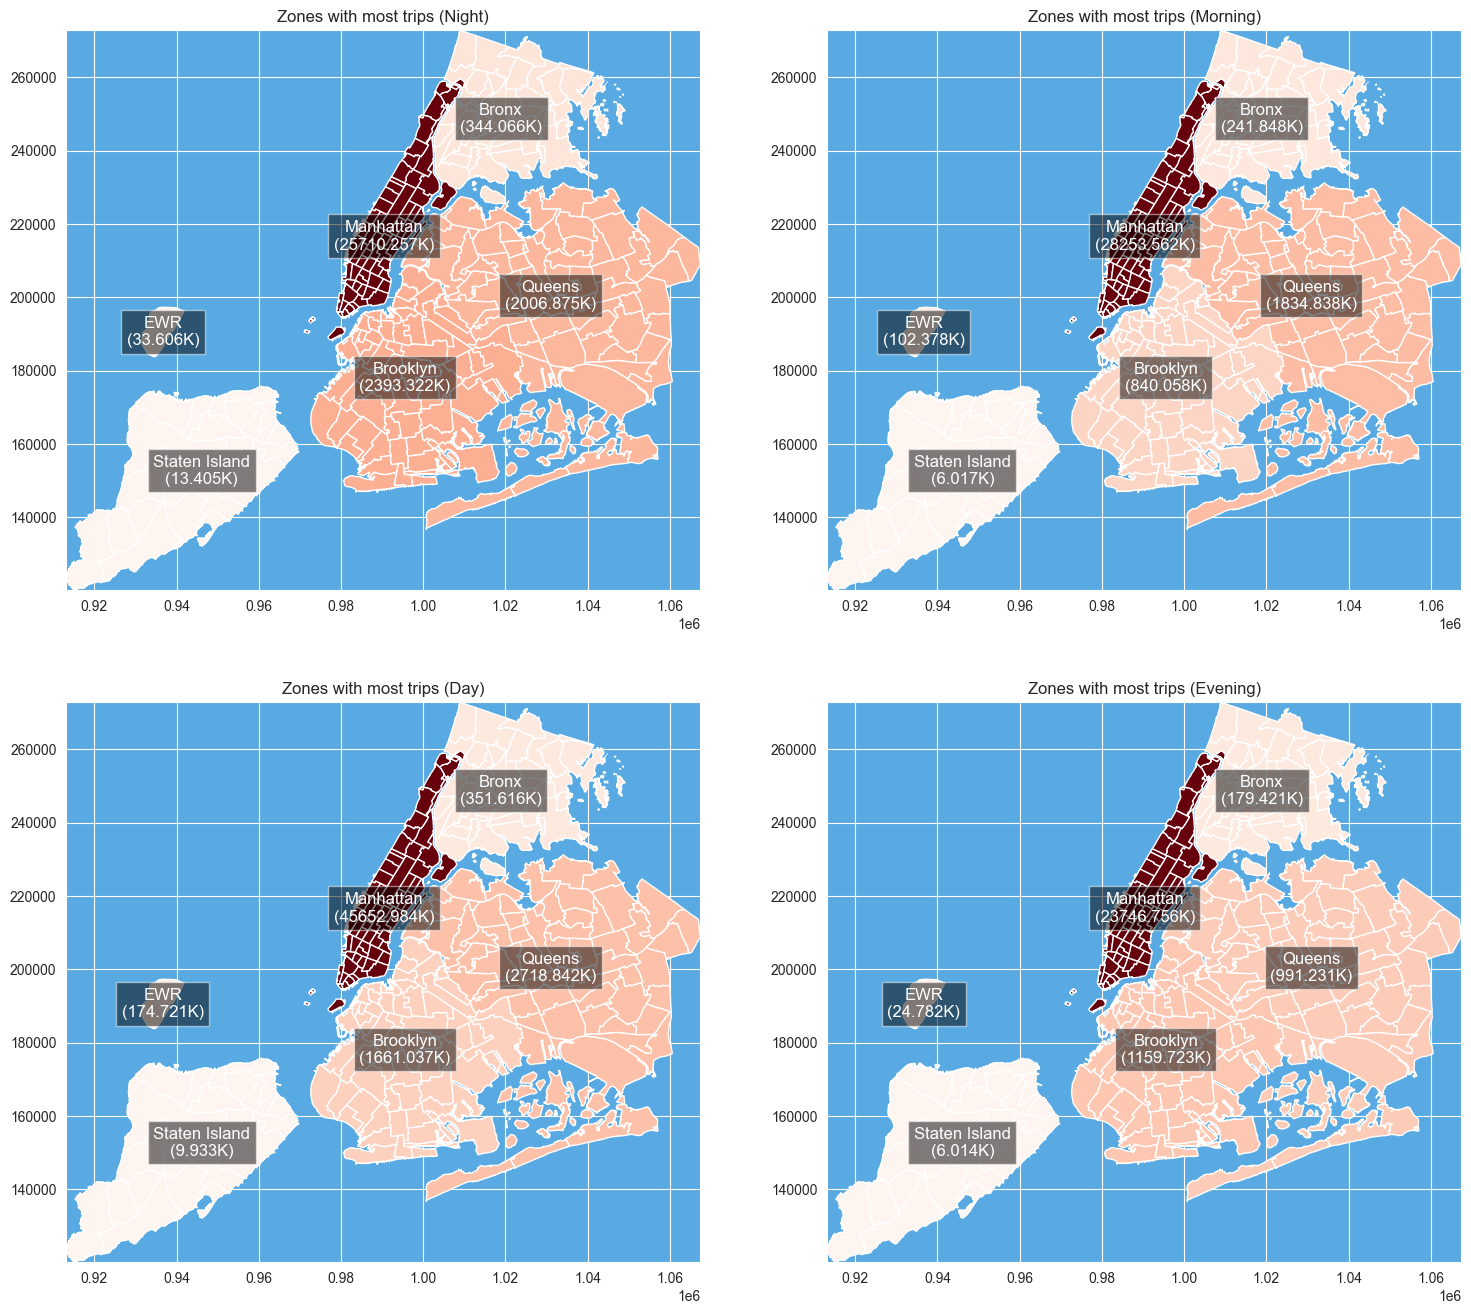

In [134]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(18,16))
ax = plt.subplot(2, 2, 1)
ax.set_title("Zones with most trips (Night)")
draw_region_map(ax, sf, heat=borough_time_of_day_dict['Night'])
ax = plt.subplot(2, 2, 2)
ax.set_title("Zones with most trips (Morning)")
draw_region_map(ax, sf, heat=borough_time_of_day_dict['Morning'])
ax = plt.subplot(2, 2, 3)
ax.set_title("Zones with most trips (Day)")
draw_region_map(ax, sf, heat=borough_time_of_day_dict['Day'])
ax = plt.subplot(2, 2, 4)
ax.set_title("Zones with most trips (Evening)")
draw_region_map(ax, sf, heat=borough_time_of_day_dict['Evening'])

Conclusions

1. **More Aggressive Tip Promotion Due to Credit Card Dominance**: The analysis reveals that credit cards are the most popular method of payment among passengers, making up a large portion of all trips. This finding suggests that a more aggressive tip promotion strategy could be implemented to encourage higher tips, particularly since passengers paying via credit card may be more inclined to leave tips electronically. By capitalizing on this behavior, taxi companies can further boost overall revenue and improve driver compensation.

2. **Popularity of Centers and Airports Distinguishing Yellow Taxit**: The data indicates that yellow taxis are significantly more concentrated in central areas and airports compared to Uber and Lyft services. This geographical distinction sets yellow taxis apart, emphasizing their role in high-traffic areas. However, the lack of trips in other regions highlights a potential weakness in the yellow taxi's network, suggesting that expanding their reach to underserved areas could offer growth opportunities. On the other hand, Uber and Lyft, with their more flexible service models, seem to have a broader geographic coverage.

3. **Fare Amount Adjustment for Peak Times**: Given the trends observed, particularly during peak travel times, it is clear that the fare amount could be adjusted dynamically. This could include implementing surge pricing during periods of high demand, such as rush hours, holidays, or other events that increase passenger traffic. Such adjustments could help balance supply and demand, maximize earnings, and improve service availability during busy times.

4. **Similar Growth Patterns Across Yellow Taxi, Uber, and Lyft**: The trip growth patterns for yellow taxis, Uber, and Lyft show a remarkable degree of similarity. This suggests that external factors, such as market-wide trends, may be influencing all services equally. Further investigation using different datasets, such as those reflecting the impact of COVID-19, weather conditions, or other socio-economic factors, could provide deeper insights into the factors driving trip volume trends. By examining such external variables, it may be possible to uncover additional insights that could help optimize service delivery for each platform.